In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

In [2]:
df = pd.read_csv("/home/attilio/VUB/PhD/GPU_BA_Thesis/mathias_code/scheduling/benchmarks/customBenchmarks/results/benchmark_attilio-vub-hp_gpubenchkit_gang_20250430_090944_236894.csv", sep=";", comment="#")

In [3]:
df["scheduled"] = df["deadline_misses"] == 0

In [4]:
df.head()

,experiment_name,benchmark_name,hostname,architecture,seed,tpc_denom,taskset_id,scheduler,rep,execution_time,jobs_completed,deadline_misses,throughput,task_system_utilization,scheduled
0,gang,gangevalbenchmark,gpubenchkit,x86_64,42,2,0,JLFP,1,5.352,60.0,27.0,11.21080,0.443953,False
1,gang,gangevalbenchmark,gpubenchkit,x86_64,42,2,0,FCFS,1,5.252,312.0,312.0,59.40590,0.443953,False
2,gang,gangevalbenchmark,gpubenchkit,x86_64,42,2,0,dumbScheduler,1,5.301,312.0,292.0,58.85680,0.443953,False
3,gang,gangevalbenchmark,gpubenchkit,x86_64,42,2,1,JLFP,1,5.130,49.0,24.0,9.55166,0.479119,False
4,gang,gangevalbenchmark,gpubenchkit,x86_64,42,2,1,FCFS,1,5.316,313.0,313.0,58.87890,0.479119,False


In [8]:
schedulability

,util_bin,scheduler,scheduled_count
0,0.05,JLFP,0
1,0.05,dumbScheduler,0
2,0.15,JLFP,0
3,0.15,dumbScheduler,0
4,0.25,JLFP,0
5,0.25,dumbScheduler,0
6,0.35,JLFP,0
7,0.35,dumbScheduler,0
8,0.45,JLFP,0
9,0.45,dumbScheduler,0


/tmp/ipykernel_87592/1174532583.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["util_bin", "scheduler"])
/tmp/ipykernel_87592/1174532583.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_per_bin = df.groupby("util_bin").size()


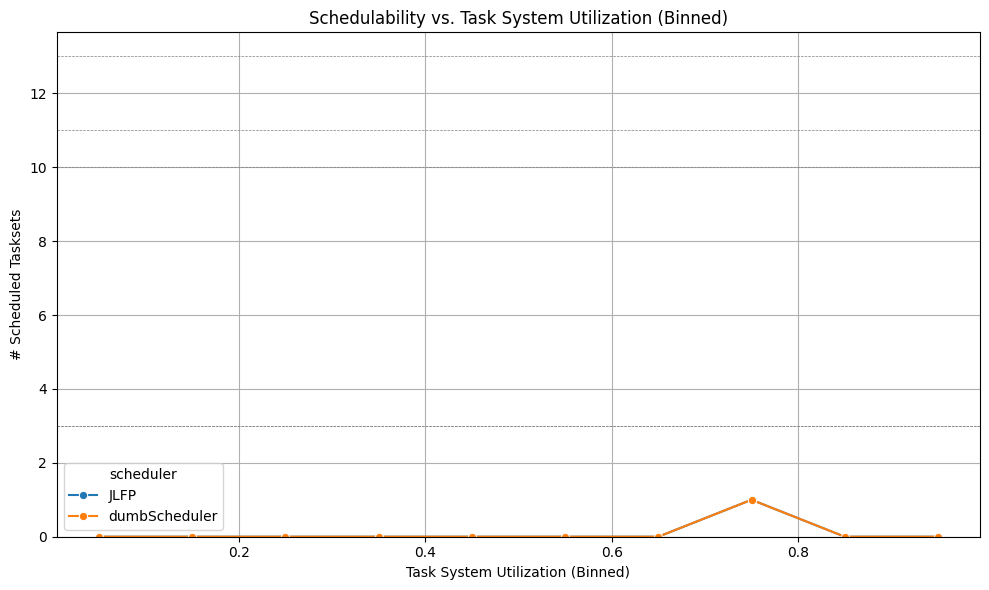

In [5]:
# Define bin edges and labels
bin_edges = np.arange(0, 1.1, 0.1)  # [0.0, 0.05, 0.10, ..., 1.0]
bin_labels = (bin_edges[:-1] + bin_edges[1:]) / 2  # label by bin centers

# Bin the utilization
df["util_bin"] = pd.cut(
    df["task_system_utilization"],
    bins=bin_edges,
    labels=bin_labels,
    include_lowest=True
)

# Group and count how many tasksets were scheduled per (bin, scheduler)
schedulability = (
    df[df["scheduled"] == True]
    .groupby(["util_bin", "scheduler"])
    .size()
    .reset_index(name="scheduled_count")
)


# Also compute total number of tasksets per bin (for horizontal reference line)
total_per_bin = df.groupby("util_bin").size()

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=schedulability,
    x="util_bin",
    y="scheduled_count",
    hue="scheduler",
    marker="o"
)

# Add horizontal lines showing the total number of tasksets per bin
for bin_center, total in total_per_bin.items():
    plt.axhline(y=total, color="gray", linestyle="--", linewidth=0.5)

# Force y-axis to start at 0
plt.ylim(bottom=0)

plt.title("Schedulability vs. Task System Utilization (Binned)")
plt.xlabel("Task System Utilization (Binned)")
plt.ylabel("# Scheduled Tasksets")
plt.grid(True)
plt.tight_layout()
plt.show()


In [6]:
df

,experiment_name,benchmark_name,hostname,architecture,seed,tpc_denom,taskset_id,scheduler,rep,execution_time,jobs_completed,deadline_misses,throughput,task_system_utilization,scheduled,util_bin
0,gang,gangevalbenchmark,gpubenchkit,x86_64,42,2,0,JLFP,1,5.352,60.0,27.0,11.21080,0.443953,False,0.45
1,gang,gangevalbenchmark,gpubenchkit,x86_64,42,2,0,FCFS,1,5.252,312.0,312.0,59.40590,0.443953,False,0.45
2,gang,gangevalbenchmark,gpubenchkit,x86_64,42,2,0,dumbScheduler,1,5.301,312.0,292.0,58.85680,0.443953,False,0.45
3,gang,gangevalbenchmark,gpubenchkit,x86_64,42,2,1,JLFP,1,5.130,49.0,24.0,9.55166,0.479119,False,0.45
4,gang,gangevalbenchmark,gpubenchkit,x86_64,42,2,1,FCFS,1,5.316,313.0,313.0,58.87890,0.479119,False,0.45
5,gang,gangevalbenchmark,gpubenchkit,x86_64,42,2,1,dumbScheduler,1,5.000,316.0,290.0,63.20000,0.479119,False,0.45
6,gang,gangevalbenchmark,gpubenchkit,x86_64,42,2,2,JLFP,1,5.549,53.0,20.0,9.55127,0.530990,False,0.55
7,gang,gangevalbenchmark,gpubenchkit,x86_64,42,2,2,FCFS,1,5.239,313.0,313.0,59.74420,0.530990,False,0.55
8,gang,gangevalbenchmark,gpubenchkit,x86_64,42,2,2,dumbScheduler,1,5.098,313.0,260.0,61.39660,0.530990,False,0.55
9,gang,gangevalbenchmark,gpubenchkit,x86_64,42,2,3,JLFP,1,5.120,51.0,26.0,9.96094,0.464361,False,0.45
